In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import importlib
import healpy as hp
import astropy.units as u
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.cm as cm

from pycorr import TwoPointEstimator, TwoPointCounter, TwoPointCorrelationFunction
from pathlib import Path

import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct
import src.analysis.plots as plots
import src.analysis.maps as maps

importlib.reload(plots)

DESI_ROOT_DR2 = Path('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP')
PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted([
    Path(
        '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/', 
        f'hsc_moc{i+1}.fits'
    )
    for i in range(0, 4)
])
cmap_hsc = plt.get_cmap('plasma')
cmap_desi = plt.get_cmap('viridis')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [4]:
importlib.reload(cf)
file_reader_xcorr = cf.CorrFileReader(f'../statistics/outputs/dr1/cross')
tgt1 = 'LRG'
tgt2 = 'HSC'

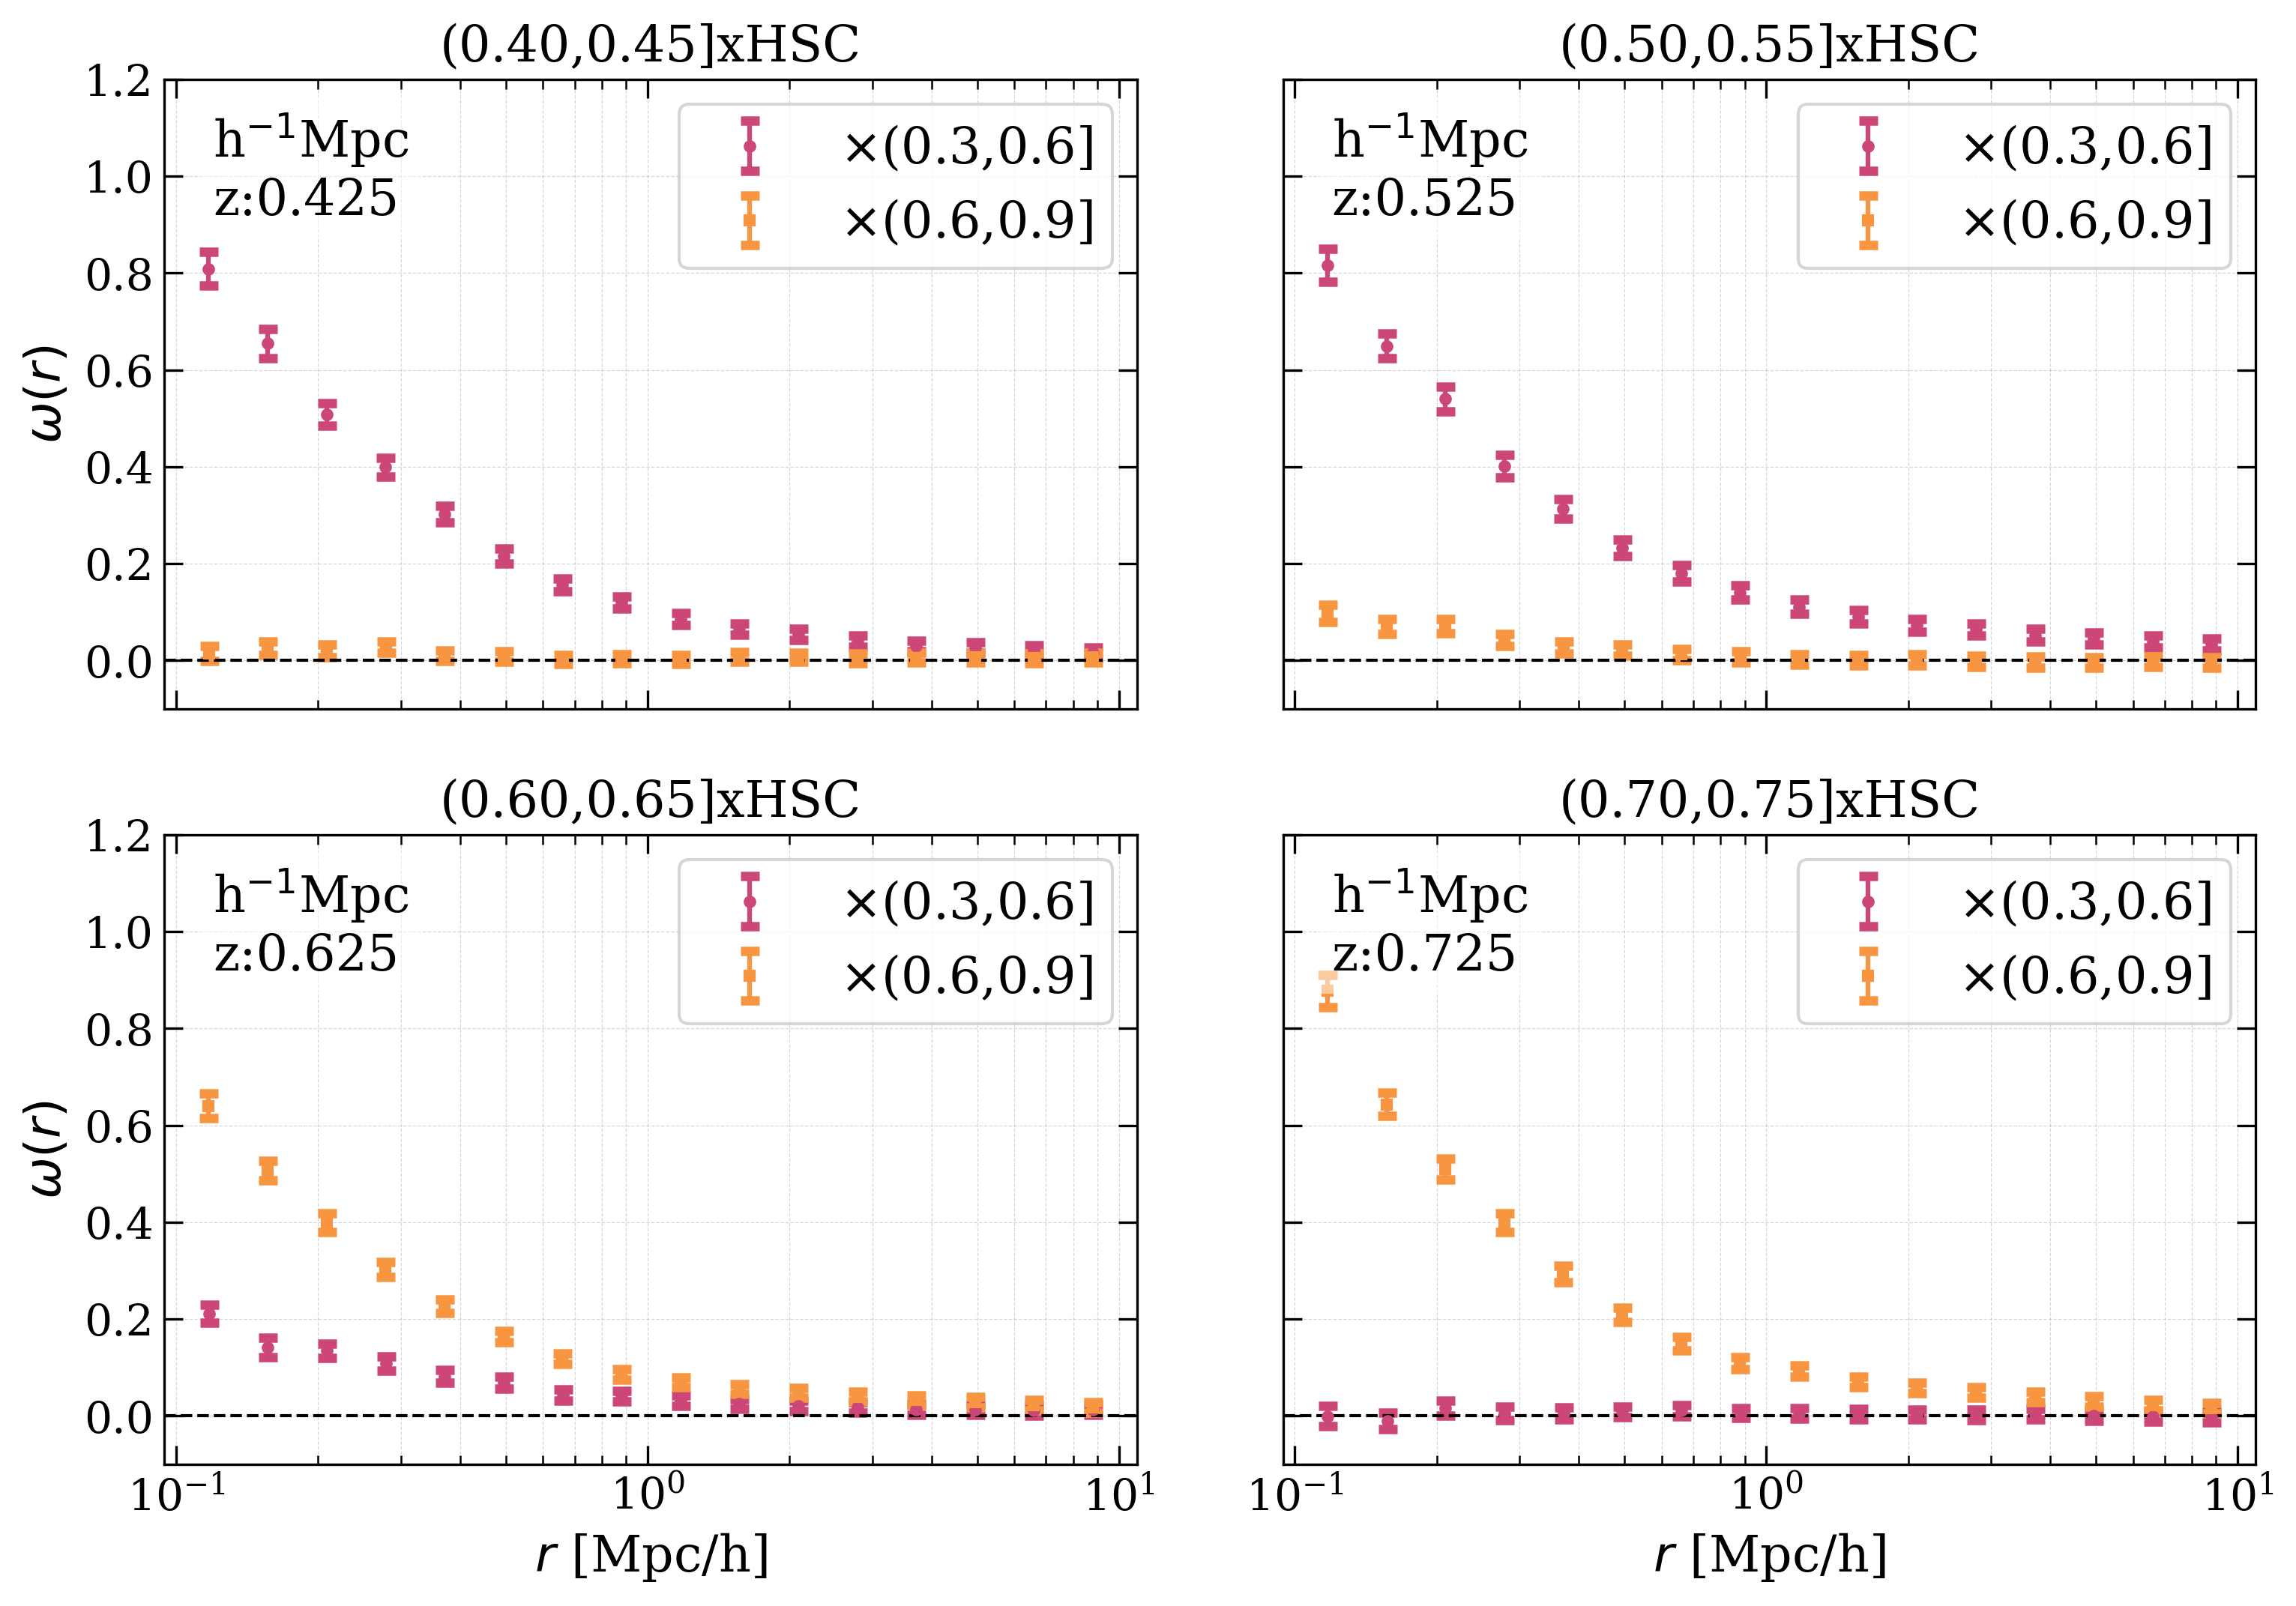

In [5]:
importlib.reload(cf)
sepmult = False
mode = 'theta' 
rebin = 2

nrows = 3
ncols = 3
bins_tgt1 = file_reader_xcorr.get_bins(tgt1)
bins_tgt2 = file_reader_xcorr.get_bins(tgt2)
cmap = plt.get_cmap('plasma')

with pm.make_plot('cross_correlation', figsize=(12, 8), ncols=2, nrows=2, sharex=True, sharey=True, tight_layout=False) as (fig, axs):
    
    # reduce wspace and hspace
    fig.subplots_adjust(wspace=0.15, hspace=0.2)
    axs = axs.flatten()
    for axi, (i, ax) in enumerate(zip(range(1, len(bins_tgt1), 2), axs)):
        for j in range(1, 3):
            nocov = False

            cov_results = [] 
            for m in range(1, 5):
                cr = TwoPointCorrelationFunction.load(
                    file_reader_xcorr.get_file(i, j, tgt1, tgt2, m)
                    )
                cov_results.append(cr)
                if len(cov_results) > 1:
                    cov_result = np.sum([cr.normalize() for cr in cov_results])
                else:
                    cov_result = cov_results[0].normalize()
                if rebin > 1:
                    cov_result.rebin(rebin)

            color = cmap((j+1)/4)

            ls = '-' 
            mark = 'o'
            if j == 2:
                ls = '--'
                mark = 's'
            if j == 3:
                ls = ':'
                mark = 'v'
            if j == 4:
                ls = '-.'
                mark = '*'
            sep = cov_result.sep
            try:
                cov = cov_result.cov()
                jackerr = np.sqrt(np.diag(cov))
            except AttributeError:
                nocov = True
                pass

            sepm = (cov_result.sep if sepmult else 1)
            rp = ct.arcsec2hMpc(cov_result.sep*3600, z=(bins_tgt1[i-1]+bins_tgt1[i])/2)
            fill = False
            if fill:
                ax.fill_between(
                    rp,
                    sepm*(cov_result.corr-jackerr),
                    sepm*(cov_result.corr+jackerr),
                    color=color,
                    alpha=0.3
                )
                ax.plot(
                    rp,
                    sepm*cov_result.corr,
                    mark,
                    color=color,
                    linestyle=ls,
                    alpha=0.8,
                    label=f'({bins_tgt2[j-1]:.1f},{bins_tgt2[j]:.1f}]'
                )
            else:
                ax.errorbar(
                    rp,
                    sepm*cov_result.corr,
                    yerr=sepm*jackerr,
                    color=color,
                    capsize=3,
                    capthick=3,
                    ms=3,
                    fmt=mark,
                    label=r'$\times$' + f'({bins_tgt2[j-1]:.1f},{bins_tgt2[j]:.1f}]'
                )

        if axi==2 or axi==3:
            if mode == 'theta':    
                ax.set_xlabel(r'$r$ [Mpc/h]', fontsize=16)
            elif mode == 'rp':
                ax.set_xlabel(r'$r$ [Mpc/h]', fontsize=16)
        if axi==0 or axi==2:
            if mode == 'theta':    
                ax.set_ylabel(r'$\omega(r)$' if not sepmult else r'$\theta \omega(\theta)$', fontsize=16)
            elif mode == 'rp':
                ax.set_ylabel(r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$', fontsize=16)

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_tgt1[i-1]:.2f},{bins_tgt1[i]:.2f}]x{tgt2}', fontsize=16)
        ax.legend(loc='upper right', fontsize=16)
        ax.tick_params(axis='both', which='major', labelsize=14)

        mid_z = (bins_tgt1[i-1] + bins_tgt1[i]) / 2

        ax.set_ylim(-0.1, 1.2)

        ax.text(
            0.05, 0.95, r'h$^{-1}$Mpc' + f'\nz:{mid_z:.3f}', 
            transform=ax.transAxes, 
            fontsize=16, 
            verticalalignment='top', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    plt.show()

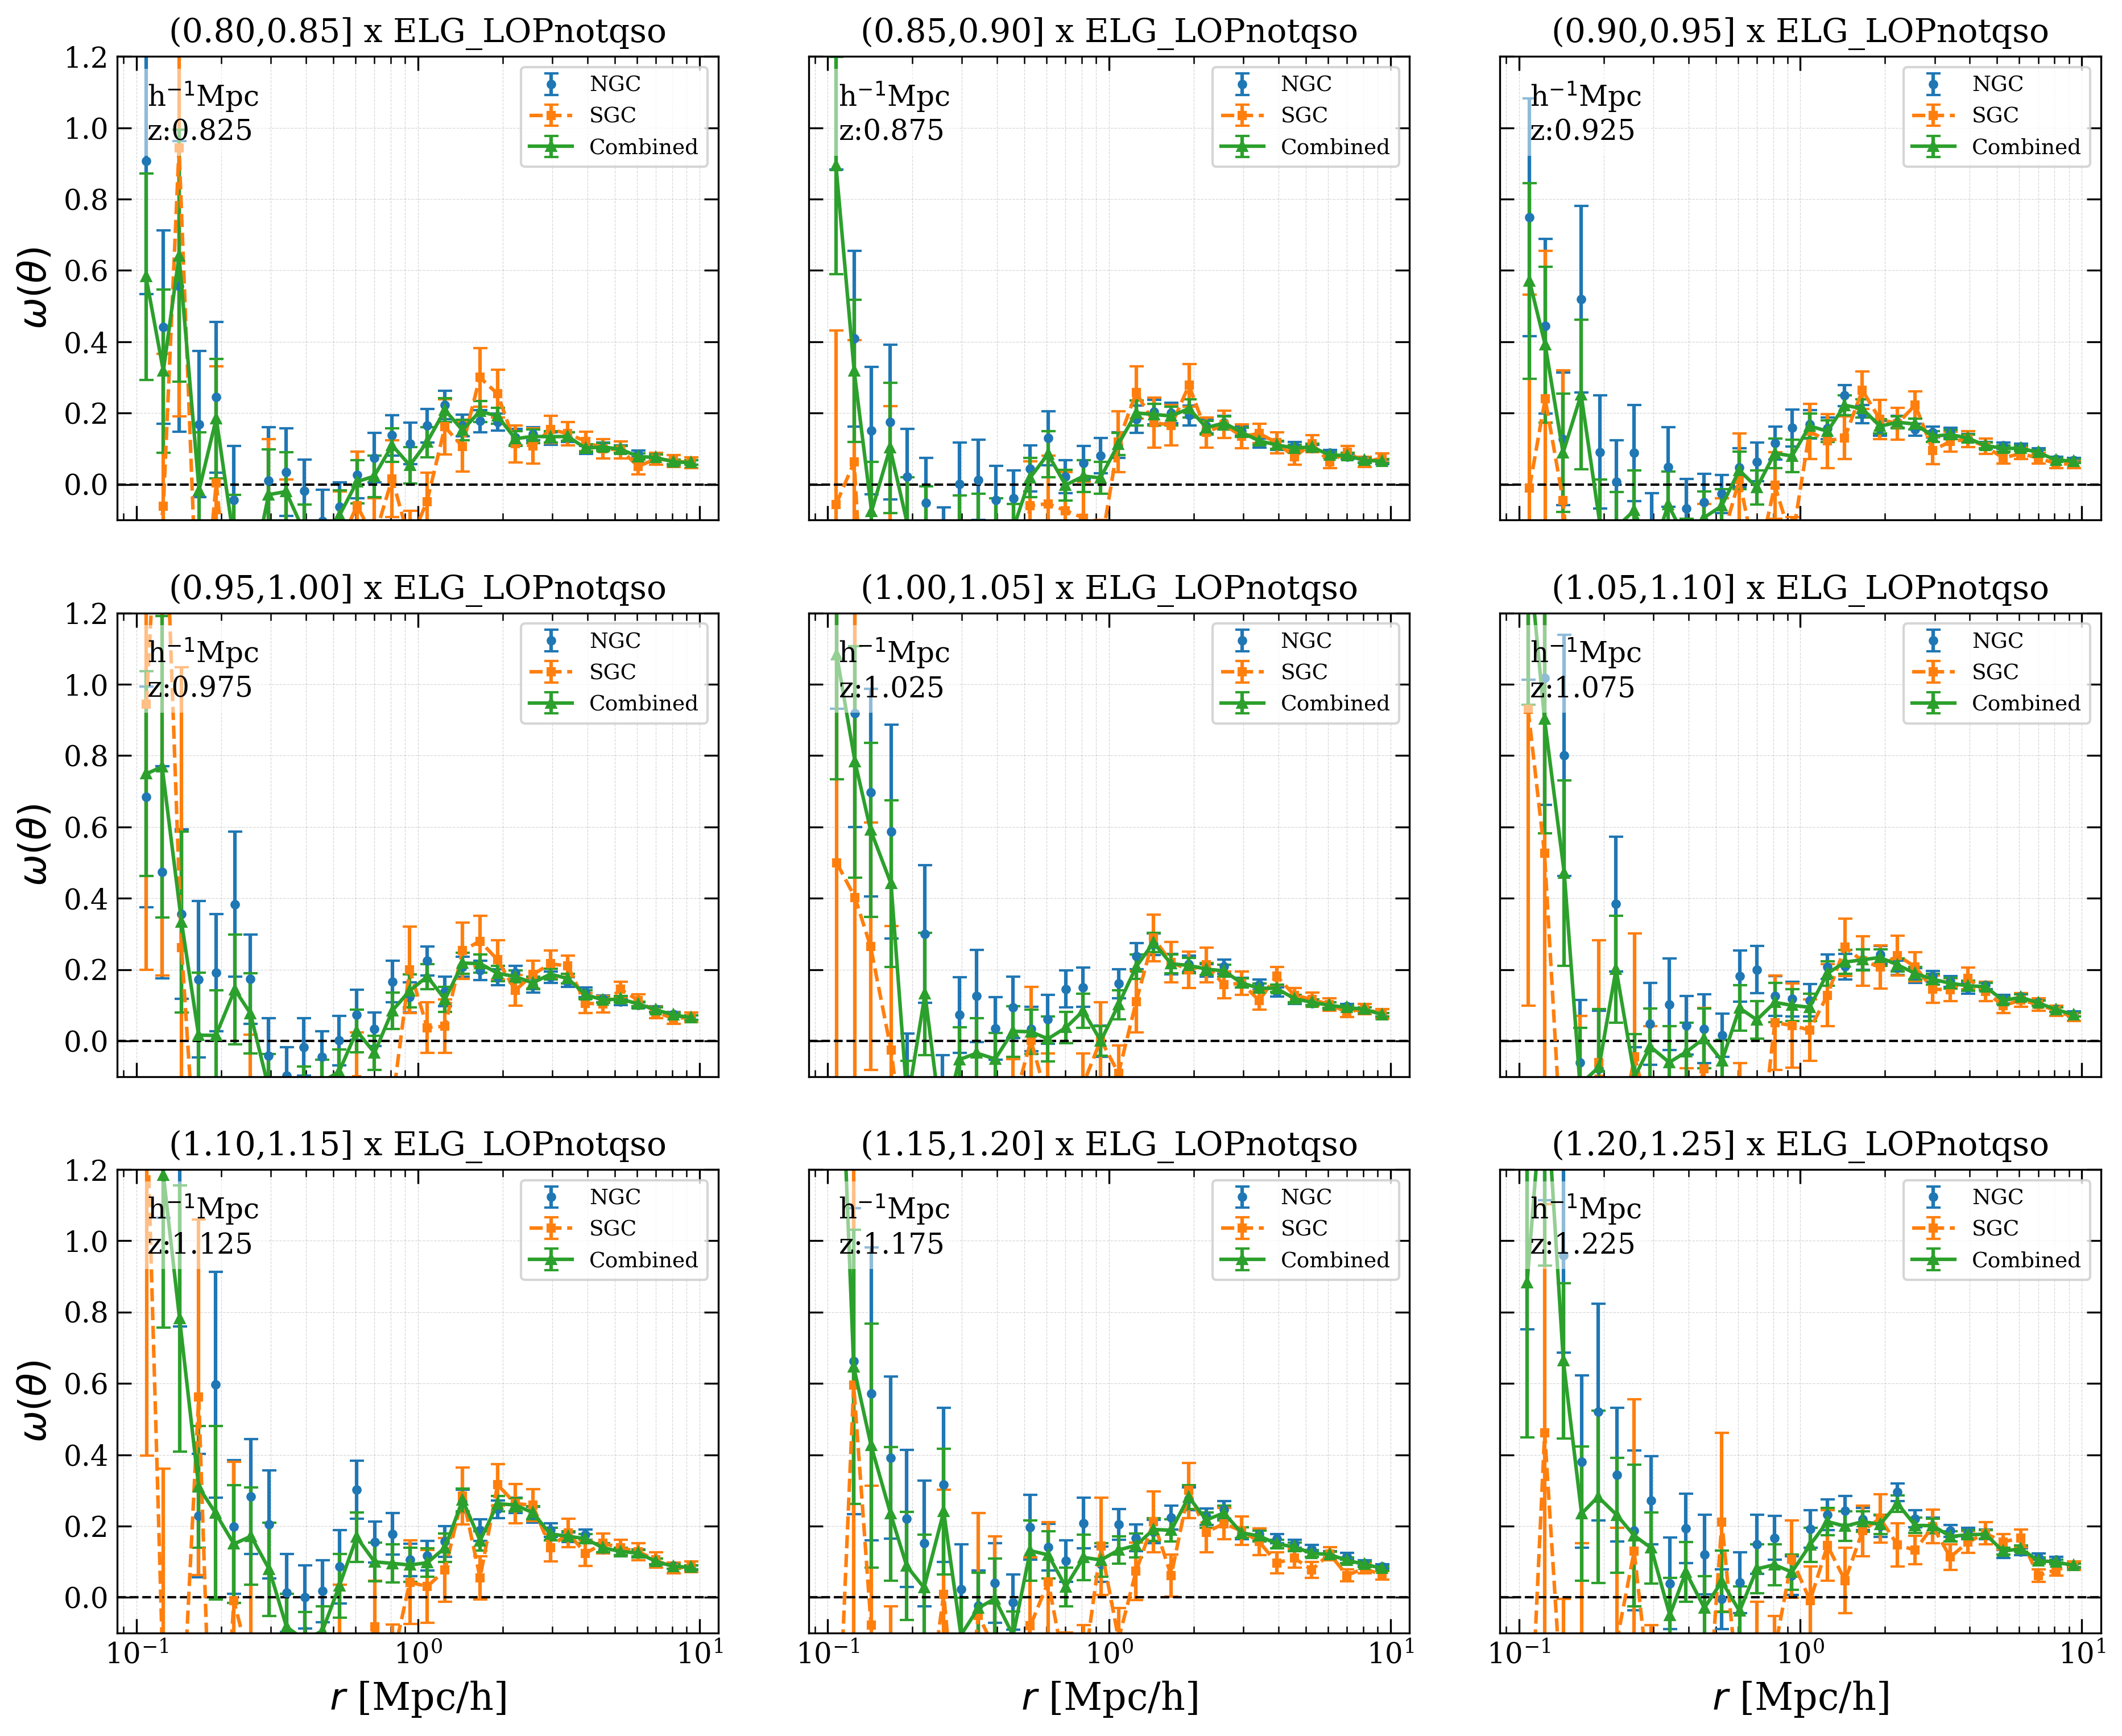

In [ ]:
# File readers for NGC and SGC
file_reader_auto_ngc = cf.CorrFileReader('../statistics/outputs/dr1/autos_NGC')
file_reader_auto_sgc = cf.CorrFileReader('../statistics/outputs/dr1/autos_SGC')

tgt = 'ELG_LOPnotqso'
nrows = 3
ncols = 3
rebin = 1
sepmult = False
mode = 'theta'

bins_ngc = file_reader_auto_ngc.get_bins(tgt)
bins_sgc = file_reader_auto_sgc.get_bins(tgt)
cmap = plt.get_cmap('plasma')

with pm.make_plot('auto_correlation_combined', figsize=(15, 12), ncols=ncols, nrows=nrows, sharex=True, sharey=True, tight_layout=False) as (fig, axs):

    fig.subplots_adjust(wspace=0.15, hspace=0.2)
    axs = axs.flatten()
    
    for axi, ax in enumerate(axs):
        if axi >= len(bins_ngc):  # skip unused subplots
            continue

        i = axi + 1  # redshift bin index (1-based)

        # Load NGC (moc=1) and SGC (moc=3), auto only (i=j)
        cr_ngc = TwoPointEstimator.load(
            file_reader_auto_ngc.get_file(i, i, tgt, tgt, 1)
        ).normalize()
        cr_sgc = TwoPointEstimator.load(
            file_reader_auto_sgc.get_file(i, i, tgt, tgt, 3)
        ).normalize()

        # Combined
        cr_comb = (cr_ngc + cr_sgc).normalize()

        # Rebin if requested
        if rebin > 1:
            cr_ngc.rebin(rebin)
            cr_sgc.rebin(rebin)
            cr_comb.rebin(rebin)

        # Separation and rp
        sepm_val = cr_comb.sep if sepmult else 1
        mid_z = (bins_ngc[i-1] + bins_ngc[i]) / 2
        rp = ct.arcsec2hMpc(cr_comb.sep * 3600, z=mid_z)

        # Errors
        def get_err(cr):
            try:
                return np.sqrt(np.diag(cr.cov()))
            except AttributeError:
                return None

        err_ngc = get_err(cr_ngc)
        err_sgc = get_err(cr_sgc)
        err_comb = get_err(cr_comb)

        # Plot NGC
        ax.errorbar(
            rp, sepm_val * cr_ngc.corr,
            yerr=sepm_val * err_ngc if err_ngc is not None else None,
            color='tab:blue', fmt='o', ms=3, capsize=3, label='NGC'
        )
        # Plot SGC
        ax.errorbar(
            rp, sepm_val * cr_sgc.corr,
            yerr=sepm_val * err_sgc if err_sgc is not None else None,
            color='tab:orange', fmt='s', ms=3, capsize=3, linestyle='--', label='SGC'
        )
        # Plot Combined
        ax.errorbar(
            rp, sepm_val * cr_comb.corr,
            yerr=sepm_val * err_comb if err_comb is not None else None,
            color='tab:green', fmt='^', ms=4, capsize=3, linestyle='-', label='Combined'
        )

        # Axis labels
        if axi in [6, 7, 8]:
            ax.set_xlabel(r'$r$ [Mpc/h]', fontsize=16)
        if axi in [0, 3, 6]:
            ax.set_ylabel(r'$w_p(r_p)$' if mode == 'rp' else r'$\omega(\theta)$', fontsize=16)

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_ngc[i-1]:.2f},{bins_ngc[i]:.2f}] x {tgt}', fontsize=14)
        ax.legend(fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_ylim(-0.3, 1.2)

        ax.text(
            0.05, 0.95, f'h$^{{-1}}$Mpc\nz:{mid_z:.3f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )

    plt.show()